# BLIP VQA: 이미지와 질문으로 짧은 답 생성하기

VQA(Visual Question Answering, 시각적 질의응답)는 **이미지와 질문을 함께 보고 짧게 답하는 작업**이다.

BLIP(블립)는 이미지와 글을 함께 처리할 수 있어 VQA에 사용할 수 있는 모델이다.

예를 들어 강아지 사진과 `어떤 동물인가?`라는 질문을 넣으면 모델은 `강아지`라고 답한다. Captioning이 사진 전체를 설명한다면 VQA는 **질문에 필요한 정보만 답한다**.

## BLIP VQA는 어떻게 답을 만드는가

BLIP VQA는 이미지를 읽고, 질문에서 원하는 정보를 찾은 뒤, 답을 한 단어씩 만든다. 강아지 사진에 `What animal is in the picture?`라고 물으면 이미지에서 동물을 찾아 `dog`라고 답한다.

이때 각 부분의 역할은 다음과 같다. 용어 이름보다 **무엇을 입력받아 무엇을 만드는지**에 집중한다.

### 핵심 용어

- **Image encoder(이미지 인코더)**: 사진을 모델이 이해할 수 있는 숫자 정보로 바꾼다.
- **Question encoder(질문 인코더)**: 질문을 읽고 무엇을 찾아야 하는지 파악한다.
- **Cross-attention(교차 어텐션)**: 질문과 관련된 이미지 부분을 골라서 참고한다.
- **Answer decoder(답변 디코더)**: 찾은 정보를 이용해 답을 한 token씩 만든다.
- **Grounding(이미지 근거 확인)**: 모델의 답과 사진에서 실제로 보이는 내용이 일치하는지 확인하는 과정이다.


### BLIP VQA 구조 그림 해석

![BLIP MED 구조](https://arxiv.org/html/2201.12086v2/MED.png)
VQA에서는 왼쪽 이미지 인코더, 가운데 질문 인코더, 오른쪽 답변 디코더가 차례로 사용된다고 읽으면 된다.

#### 1. 이미지 특징 만들기

왼쪽의 image encoder가 강아지 사진을 숫자 정보로 바꾼다.

#### 2. 질문을 이미지에 연결하기

가운데 부분이 `What animal is in the picture?`라는 질문을 읽는다. Cross-attention은 질문과 관련된 강아지 부분에 집중하게 한다.

#### 3. 짧은 답 생성하기

오른쪽의 answer decoder가 앞에서 찾은 정보를 이용해 `dog`라는 짧은 답을 만든다.

```text
강아지 이미지 + "What animal is in the picture?"
→ 이미지 특징과 질문 연결
→ "dog"
```

> **핵심**: 같은 사진이라도 질문이 달라지면 모델이 찾아야 할 정보와 답도 달라진다.

출처: Li et al., *BLIP: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation* (2022), Figure 2, [arXiv:2201.12086v2](https://arxiv.org/html/2201.12086v2#S2.F2), CC BY 4.0


## 이미지와 질문을 모델 입력으로 바꾸기

모델은 이미지 파일과 문장을 그대로 읽지 못하므로 숫자로 바꿔야 한다. `BlipProcessor`가 이미지와 질문을 다음 세 가지 tensor로 바꾼다. Tensor는 여러 숫자를 담은 다차원 배열이고, token은 문장을 나누어 처리하는 작은 단위이다.

- **`pixel_values`**: 크기와 값의 범위를 맞춘 이미지 숫자
- **`input_ids`**: 질문의 각 token을 정수 번호로 바꾼 값
- **`attention_mask`**: 질문에서 실제로 읽어야 할 token의 위치를 표시한 값

다음 코드는 BLIP의 실제 답 생성 방식이 아니다. 미리 적어 둔 완성 답 후보 중 점수가 가장 큰 항목을 고르는 간단한 Python 예제로, 실제 모델을 실행하기 전에 입력 이름과 점수 비교만 확인한다.


In [1]:
# 이미지를 베이스로한 간단한 질문
question = "What animal is in the image?"

# processor()가 만들 입력 양식 구조 예시
input_roles = {
    "이미지 입력": "pixel_values", # 이미지
    "질문 token": "input_ids", # 질문(텍스트) -> 토큰 id
    "질문 mask": "attention_mask",
}
answer_candidates = [
    {"answer": "a dog", "score": -0.3},
    {"answer": "a golden retriever", "score": -0.6},
    {"answer": "an animal", "score": -1.4},
]
best_answer = max(answer_candidates, key=lambda candidate: candidate["score"])["answer"]

for role, key in input_roles.items():
    print(f"{role}: {key}")
print("질문 단어 수(공백 기준):", len(question.rstrip("?").split()))
print("선택된 짧은 답변:", best_answer)
print("답변 단어 수(공백 기준):", len(best_answer.split()))

이미지 입력: pixel_values
질문 token: input_ids
질문 mask: attention_mask
질문 단어 수(공백 기준): 6
선택된 짧은 답변: a dog
답변 단어 수(공백 기준): 2


## 예제 이미지와 질문 준비

다음 셀은 URL에서 예제 이미지를 내려받아 RGB 형식으로 바꾸고, 이미지에 물어볼 질문을 함께 준비한다. 만들어진 `image`와 `question`은 다음 셀에서 VQA 모델의 두 입력으로 사용한다.

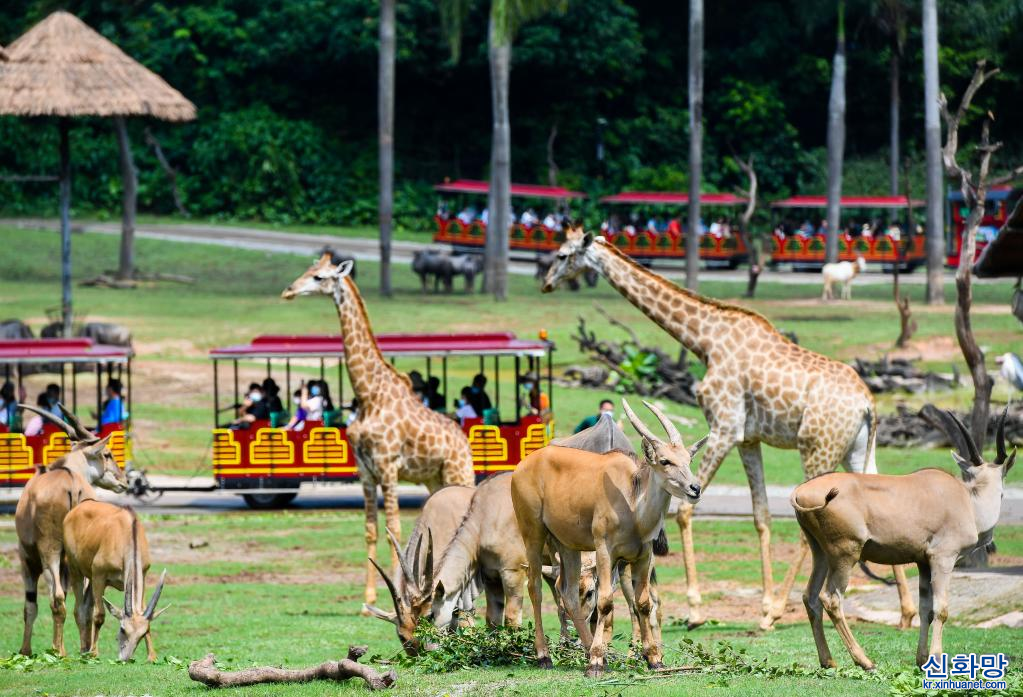

question: What kind of animals are in the picture?


In [14]:
from io import BytesIO

import requests
from IPython.display import display
from PIL import Image

# DEMO_IMAGE_URL = "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg"
DEMO_IMAGE_URL = "https://kr.news.cn/20220710/973a6809e0ce4bbda01e98b07ee25c0b/20220710973a6809e0ce4bbda01e98b07ee25c0b_2022071080b8e8982e9d4b7eb9dc5ab7401000cb.jpg"
question = "What kind of animals are in the picture?"

response = requests.get(DEMO_IMAGE_URL, timeout=30)
response.raise_for_status()
image = Image.open(BytesIO(response.content)).convert("RGB")
display(image)
print("question:", question)

## 실제 BLIP VQA로 답 만들기

이미지와 질문을 실제 BLIP VQA 모델에 함께 넣는다. `BlipProcessor`가 두 입력을 숫자로 바꾸고, `BlipForQuestionAnswering`이 질문과 관련된 이미지 정보를 찾아 짧은 답을 만든다.

`model.generate()`가 답변 token을 생성한다. `max_new_tokens=10`은 답의 최대 길이를 제한하고, `num_beams=3`은 매 단계에서 답 후보 3개를 비교하게 한다. 마지막에 `decode()`가 token 번호를 사람이 읽을 수 있는 글자로 바꾼다.



In [3]:
import torch
from transformers import BlipForQuestionAnswering, BlipProcessor

MODEL_ID = "Salesforce/blip-vqa-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = BlipProcessor.from_pretrained(MODEL_ID)
model = BlipForQuestionAnswering.from_pretrained(MODEL_ID).to(device)
model.eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

C:\Users\playdata2\miniforge3\envs\llm_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\playdata2\.cache\huggingface\hub\models--Salesforce--blip-vqa-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

BlipForQuestionAnswering(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        )
      )
    )
    (post_layernorm): LayerNor

### 이미지와 질문으로 답 생성하기

앞 셀에서 VQA 모델을 준비했다. 다음 코드는 `image`와 `question`을 모델 입력으로 바꾸고, 질문과 관련된 이미지 정보를 참고해 답 token을 생성한 뒤 글자로 되돌린다. 실행 후에는 세 입력의 shape와 최종 `answer`를 확인한다.

In [ ]:
import os
os.environ['USE_TF'] = '0'

inputs = processor(
    images=image,
    text=question, # 질문
    return_tensors="pt",
).to(device)

# 이미지 + 질문에 대한 답변(토큰 ID 목록) 반환
with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens = 30,
        num_beams = 3
    )

answer = processor.decode(
    output_ids[0],
    skip_special_tokens=True,
)

display(image)
print("question: ", question)
print("answer: ", answer)

## 답이 이미지에 근거했는지 확인하기

VQA의 답은 이미지에서 확인할 수 있어야 한다. 같은 사진이라도 `어떤 동물인가?`는 동물의 종류를 묻고, `동물이 무엇을 하고 있는가?`는 행동을 묻기 때문에 서로 다른 답이 나와야 한다.

모델은 사진에서 알 수 없는 내용도 그럴듯하게 답할 수 있다. 따라서 답이 자연스러운지만 보지 말고, **사진에서 실제로 확인할 수 있는 답인지** 반드시 점검한다. 이것이 grounding 확인이다.

이 모델의 공식 예제는 영어 중심이다. 영어 질문에서 잘 동작하더라도 한국어 질문에서도 같은 성능이 나온다고 볼 수 없으므로 한국어 질문은 별도로 시험해야 한다.